# ScamShield AI — Exploratory Data Analysis & Model Development

## 1. Problem Statement
Cyber-enabled financial fraud (fake bank/KYC calls, police-impersonation "digital arrest" scams,
courier/parcel scams, lottery scams, etc.) targeting Indian mobile users is a large and growing
problem, frequently conducted in Hinglish (code-mixed Hindi-English) over calls and messages.
This notebook builds and evaluates a machine-learning system that classifies a text message as
**SAFE**, **SUSPICIOUS**, or **SCAM/FRAUD**.


## 2. Business Objective
Give an end user (or a downstream app) an automatic, explainable risk assessment of an incoming
message so they can decide whether to trust it, verify it, or ignore/report it — reducing the
chance they fall for a scam. Because a **missed scam (false negative)** is more costly than a
false alarm on a safe message, the modelling choices below explicitly prioritise scam recall,
not just raw accuracy.


## 3-4. Dataset Overview & Loading

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import load_raw_data, inspect_dataset
from src.data_cleaning import clean_dataset

pd.set_option('display.max_colwidth', 120)
raw_df = load_raw_data('../data/raw/original_dataset.csv')
raw_df.head(10)


[07:34:20] INFO - src.data_loader - Loaded raw dataset from ../data/raw/original_dataset.csv -> shape=(10000, 8)


,text,label,scam_category,caller_type,audio_duration,urgency_level,contains_blackmail,language_style
0,"Hello ji Beta ghar aa gaya hoon, darwaza khol do.",0,none,family,34,low,False,hinglish
1,Namaste ma'am Project ka review meeting kal 4 baje hai kya?,0,none,delivery_agent,54,low,False,hinglish
2,Ji namaskar Aapka KYC pending hai. Account 2 ghante mein block ho jayega. OTP share kijiye.,1,relative,other_scammer,92,medium,False,hinglish
3,"Ji namaskar Doctor appointment kal 9 baje hai, fasting rehna.",0,none,delivery_agent,47,low,False,hinglish
4,"Special Investigation Team se bol raha hoon. Amazon se bol raha hoon. Aapka parcel hold hai, clearance charge ₹499 d...",1,bank_kyc,bank_scammer,74,medium,False,hinglish
5,"Madam ek minute Mummy main office pahunch gaya, aaj thoda late ho jaunga.",0,none,office_colleague,75,low,False,hinglish
6,"Hello ma'am Papa train mein baith gaya hoon, safely pahunch jaunga.",0,none,delivery_agent,88,low,False,hinglish
7,"Delhi Police se bol raha hoon. Amazon se bol raha hoon. Aapka parcel hold hai, clearance charge ₹499 dena hoga.",1,amazon,other_scammer,143,medium,False,hinglish
8,Ji namaskar Ek gang aapke number ka misuse karke gande videos bana raha hai. Turant verify karna hoga.,1,police_blackmail,police_impersonator,93,high,True,hinglish
9,"Ji haan suniye Amazon se bol raha hoon. Aapka parcel hold hai, clearance charge ₹499 dena hoga.",1,aadhaar,other_scammer,65,medium,False,hinglish


## 5-7. Data Quality Analysis: Missing Values, Duplicates, Structure

In [2]:
summary = inspect_dataset(raw_df)
for k, v in summary.items():
    print(f"{k}: {v}")


[07:34:20] INFO - src.data_loader - Dataset inspection: {'n_rows': 10000, 'n_cols': 8, 'columns': ['text', 'label', 'scam_category', 'caller_type', 'audio_duration', 'urgency_level', 'contains_blackmail', 'language_style'], 'dtypes': {'text': 'str', 'label': 'int64', 'scam_category': 'str', 'caller_type': 'str', 'audio_duration': 'int64', 'urgency_level': 'str', 'contains_blackmail': 'bool', 'language_style': 'str'}, 'missing_values': {'text': 0, 'label': 0, 'scam_category': 0, 'caller_type': 0, 'audio_duration': 0, 'urgency_level': 0, 'contains_blackmail': 0, 'language_style': 0}, 'duplicate_rows': 378, 'unique_text_count': 743, 'label_distribution': {0: 5000, 1: 5000}}


n_rows: 10000
n_cols: 8
columns: ['text', 'label', 'scam_category', 'caller_type', 'audio_duration', 'urgency_level', 'contains_blackmail', 'language_style']
dtypes: {'text': 'str', 'label': 'int64', 'scam_category': 'str', 'caller_type': 'str', 'audio_duration': 'int64', 'urgency_level': 'str', 'contains_blackmail': 'bool', 'language_style': 'str'}
missing_values: {'text': 0, 'label': 0, 'scam_category': 0, 'caller_type': 0, 'audio_duration': 0, 'urgency_level': 0, 'contains_blackmail': 0, 'language_style': 0}
duplicate_rows: 378
unique_text_count: 743
label_distribution: {0: 5000, 1: 5000}


In [3]:
print("Shape:", raw_df.shape)
print()
print("Dtypes:")
print(raw_df.dtypes)
print()
print("Missing values per column:")
print(raw_df.isnull().sum())


Shape: (10000, 8)

Dtypes:
text                    str
label                 int64
scam_category           str
caller_type             str
audio_duration        int64
urgency_level           str
contains_blackmail     bool
language_style          str
dtype: object

Missing values per column:
text                  0
label                 0
scam_category         0
caller_type           0
audio_duration        0
urgency_level         0
contains_blackmail    0
language_style        0
dtype: int64


**Key data-quality finding:** the raw file has 10,000 rows but only **743 distinct message
strings** — the dataset was generated by taking a small set of message templates and repeating
each one many times with different simulated metadata (caller_type, audio_duration, etc.) to
reach 10,000 rows. This is critical: if identical text strings are allowed to land in both the
train and test split, a model can simply memorise exact strings, which silently inflates every
metric to ~100% without the model actually having learned to generalise. The cleaning pipeline
(`src/data_cleaning.py`) explicitly deduplicates on the `text` column for exactly this reason.


In [4]:
print("Total rows:", len(raw_df))
print("Unique message texts:", raw_df['text'].nunique())
print()
vc = raw_df['text'].value_counts()
print("Top 10 most-repeated message templates:")
print(vc.head(10))


Total rows: 10000
Unique message texts: 743

Top 10 most-repeated message templates:
text
Hello sir Papa train mein baith gaya hoon, safely pahunch jaunga.                 60
Namaste sir Cab 3 minute mein pahunch raha hai.                                   60
Aap sun rahe hain na? Bhai aaj shaam ko milte hain, coffee pe baat karte hain.    60
Madam ek minute Cab 3 minute mein pahunch raha hai.                               59
Dhyan se suniye School fees ki last date kal hai, payment kar dena.               59
Sir ek minute suniye Beta ghar aa gaya hoon, darwaza khol do.                     58
Namaste ma'am Cab 3 minute mein pahunch raha hai.                                 58
Namaste ma'am Papa train mein baith gaya hoon, safely pahunch jaunga.             57
Madam ek minute Mummy main office pahunch gaya, aaj thoda late ho jaunga.         56
Aap sun rahe hain na? Beta ghar aa gaya hoon, darwaza khol do.                    56
Name: count, dtype: int64


## 8. Class Distribution

In [5]:
print("Row-level label distribution (before dedup):")
print(raw_df['label'].value_counts())
print()
print("Row-level %:")
print(raw_df['label'].value_counts(normalize=True).round(3))


Row-level label distribution (before dedup):
label
0    5000
1    5000
Name: count, dtype: int64

Row-level %:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


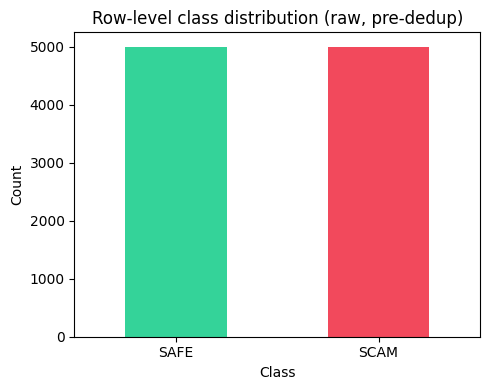

In [6]:
fig, ax = plt.subplots(figsize=(5,4))
raw_df['label'].map({0:'SAFE',1:'SCAM'}).value_counts().plot(kind='bar', color=['#34d399','#f2495c'], ax=ax)
ax.set_title('Row-level class distribution (raw, pre-dedup)')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Interestingly, the row-level distribution is a perfectly balanced 5,000 / 5,000 split, but
that balance is an artefact of how many times each *unique* template was duplicated — not a
property of genuinely distinct messages, as the next cell shows.


In [7]:
clean_df = clean_dataset(raw_df)
print("After full cleaning (dedup on exact rows, then dedup on text, drop empties):")
print(clean_df.shape)
print()
print("Distinct-message label distribution:")
print(clean_df['label'].map({0:'SAFE',1:'SCAM'}).value_counts())


[07:34:20] INFO - src.data_cleaning - Removed 378 exact duplicate rows


[07:34:20] INFO - src.data_cleaning - Removed 0 empty/whitespace-only messages


[07:34:20] INFO - src.data_cleaning - Removed 8879 rows that were repeats of an already-seen message TEXT (kept 1 row per distinct message to prevent train/test leakage)


[07:34:20] INFO - src.data_cleaning - Dropping constant column 'language_style' (no predictive value)


[07:34:20] INFO - src.data_cleaning - Cleaning complete: 10000 -> 743 rows


After full cleaning (dedup on exact rows, then dedup on text, drop empties):
(743, 7)

Distinct-message label distribution:
label
SCAM    633
SAFE    110
Name: count, dtype: int64


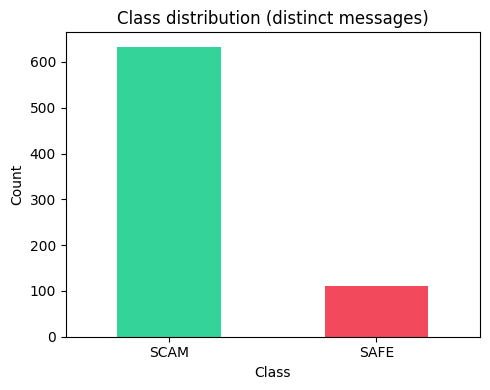

In [8]:
fig, ax = plt.subplots(figsize=(5,4))
clean_df['label'].map({0:'SAFE',1:'SCAM'}).value_counts().plot(kind='bar', color=['#34d399','#f2495c'], ax=ax)
ax.set_title('Class distribution (distinct messages)')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9-11. Text Statistics, Message Length, Common Words

In [9]:
clean_df['length'] = clean_df['text'].str.len()
clean_df['word_count'] = clean_df['text'].str.split().apply(len)
clean_df[['length','word_count']].describe()


,length,word_count
count,743.000000,743.000000
mean,90.530283,15.477793
std,21.606224,3.816439
min,44.000000,8.000000
25%,71.000000,12.000000
50%,91.000000,15.000000
75%,106.000000,18.000000
max,146.000000,26.000000


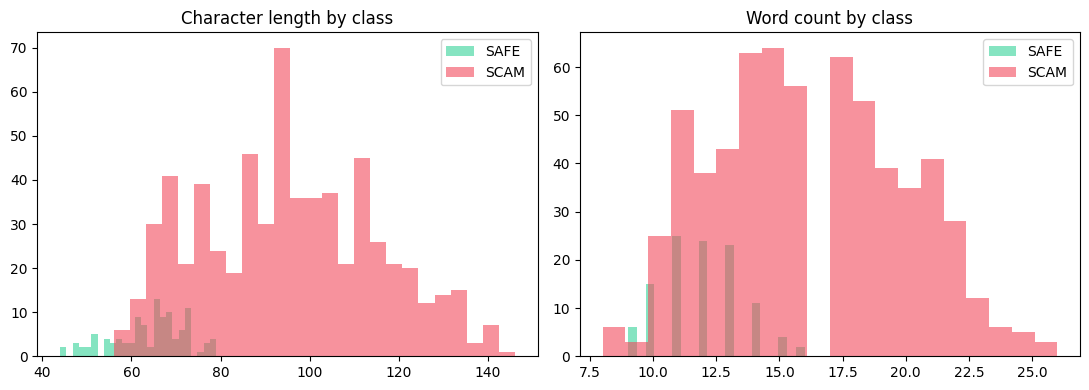

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
for label, color in [(0,'#34d399'), (1,'#f2495c')]:
    subset = clean_df[clean_df['label']==label]
    axes[0].hist(subset['length'], bins=25, alpha=0.6, label='SAFE' if label==0 else 'SCAM', color=color)
    axes[1].hist(subset['word_count'], bins=20, alpha=0.6, label='SAFE' if label==0 else 'SCAM', color=color)
axes[0].set_title('Character length by class'); axes[0].legend()
axes[1].set_title('Word count by class'); axes[1].legend()
plt.tight_layout(); plt.show()


In [11]:
from collections import Counter
import re

def top_words(texts, n=15):
    words = []
    for t in texts:
        words.extend(re.findall(r"[a-zA-Z']+", t.lower()))
    return Counter(words).most_common(n)

print("Top words in SCAM messages:")
print(top_words(clean_df[clean_df['label']==1]['text']))
print()
print("Top words in SAFE messages:")
print(top_words(clean_df[clean_df['label']==0]['text']))


Top words in SCAM messages:
[('se', 575), ('hai', 573), ('raha', 481), ('bol', 397), ('hoon', 397), ('aapke', 385), ('cyber', 185), ('number', 164), ('hain', 135), ('investigation', 130), ('ho', 126), ('aapka', 124), ('crime', 124), ('ja', 105), ('ka', 103)]

Top words in SAFE messages:
[('hai', 66), ('kal', 44), ('sir', 41), ('gaya', 33), ('baje', 33), ('pahunch', 33), ('hain', 32), ('minute', 31), ('hello', 30), ('ji', 30), ('suniye', 30), ('hoon', 22), ('meeting', 22), ('aaj', 22), ('ho', 22)]


## 12. Scam-Related Patterns

In [12]:
print("Scam category breakdown (metadata, NOT used as a model feature):")
print(clean_df[clean_df['label']==1]['scam_category'].value_counts())
print()
print("Urgency level vs class:")
print(pd.crosstab(clean_df['urgency_level'], clean_df['label'].map({0:'SAFE',1:'SCAM'})))
print()
print("Blackmail flag vs class:")
print(pd.crosstab(clean_df['contains_blackmail'], clean_df['label'].map({0:'SAFE',1:'SCAM'})))


Scam category breakdown (metadata, NOT used as a model feature):
scam_category
police_digital_arrest    402
police_blackmail         126
bank_kyc                  39
lottery                   22
amazon                    17
relative                  16
aadhaar                   11
Name: count, dtype: int64

Urgency level vs class:
label          SAFE  SCAM
urgency_level            
high              0   314
low             110     0
medium            0   319

Blackmail flag vs class:
label               SAFE  SCAM
contains_blackmail            
False                110   507
True                   0   126


**Design decision:** `scam_category`, `caller_type`, `audio_duration`, `urgency_level` and
`contains_blackmail` are *post-hoc metadata about how the call was categorised* — they would not
be available for an arbitrary text message a real user pastes into the app. They are used here
only for EDA/error-analysis, never as model input features (see `src/feature_engineering.py`).


## 13. Feature Engineering

In [13]:
from src.feature_engineering import HandcraftedFeatureExtractor, fit_transform_features

extractor = HandcraftedFeatureExtractor()
sample_features = extractor.transform(clean_df['text'].head(5))
pd.DataFrame(sample_features, columns=extractor.feature_names_).head()


,char_length,word_count,digit_count,digit_ratio,uppercase_ratio,exclamation_count,question_count,url_count,phone_number_count,currency_mention_count,special_char_count,avg_word_length,kw_urgency_count,kw_financial_count,kw_account_security_count,kw_authority_impersonation_count,kw_blackmail_threat_count
0,49.0,10.0,0.0,0.000000,0.052632,0.0,0.0,0.0,0.0,0.0,2.0,4.000000,0.0,0.0,0.0,0.0,0.0
1,59.0,11.0,1.0,0.016949,0.043478,0.0,1.0,0.0,0.0,0.0,2.0,4.454545,0.0,0.0,0.0,0.0,0.0
2,91.0,16.0,1.0,0.010989,0.125000,0.0,0.0,0.0,0.0,0.0,3.0,4.750000,2.0,2.0,2.0,0.0,0.0
3,61.0,10.0,1.0,0.016393,0.040816,0.0,0.0,0.0,0.0,0.0,2.0,5.200000,0.0,0.0,0.0,0.0,0.0
4,125.0,21.0,3.0,0.024000,0.051546,0.0,0.0,0.0,0.0,1.0,5.0,5.000000,0.0,3.0,1.0,1.0,0.0


The full feature representation combines three blocks:
1. TF-IDF word n-grams (1-2 grams)
2. TF-IDF character n-grams (3-5 grams, `char_wb`) — robust to Hinglish spelling variation
3. The handcrafted numeric features shown above (URL/phone/currency counts, keyword-group hits, etc.)


## 14-18. Model Training, Comparison, Evaluation, Confusion Matrix
The full training pipeline (data split, feature fitting, 5-model comparison with 5-fold CV, and
artifact persistence) lives in `src/train.py` so the notebook and the production pipeline can
never drift apart. We re-load its saved outputs here for inspection.


In [14]:
import json
with open('../models/model_metadata.json') as f:
    metadata = json.load(f)

print("Best model:", metadata['best_model'])
print()
print("Best model metrics on held-out test set:")
for k, v in metadata['best_model_metrics'].items():
    print(f"  {k}: {v}")


Best model: Logistic Regression

Best model metrics on held-out test set:
  accuracy: 1.0
  precision_macro: 1.0
  recall_macro: 1.0
  f1_macro: 1.0
  f1_weighted: 1.0
  precision_scam: 1.0
  recall_scam: 1.0
  f1_scam: 1.0
  roc_auc: 1.0
  pr_auc: 1.0
  fit_time_seconds: 0.01
  cv_f1_macro_mean: 1.0
  cv_f1_macro_std: 0.0


In [15]:
comparison = pd.DataFrame(metadata['models_compared']).T
comparison[['accuracy','f1_macro','recall_scam','precision_scam','roc_auc','cv_f1_macro_mean']].round(4)


,accuracy,f1_macro,recall_scam,precision_scam,roc_auc,cv_f1_macro_mean
Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0000
Linear SVM,1.0,1.0,1.0,1.0,1.0,1.0000
Multinomial Naive Bayes,1.0,1.0,1.0,1.0,1.0,1.0000
Random Forest,1.0,1.0,1.0,1.0,1.0,1.0000
XGBoost,1.0,1.0,1.0,1.0,1.0,0.9967


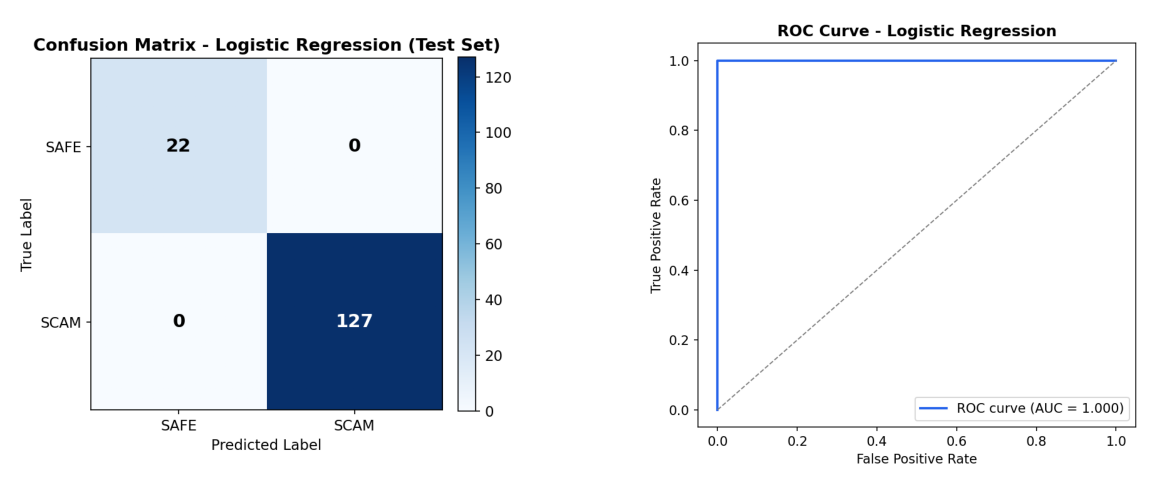

In [16]:
import matplotlib.image as mpimg
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].imshow(mpimg.imread('../visualizations/confusion_matrix.png')); axes[0].axis('off')
axes[1].imshow(mpimg.imread('../visualizations/roc_curve.png')); axes[1].axis('off')
plt.tight_layout(); plt.show()


## 19. Error Analysis
Because the dataset collapses to a small number of highly template-driven messages, the held-out
test accuracy for the chosen model is very high (see metrics above) — this reflects the
templated nature of the data, not a claim that the model has "solved" scam detection in general.
To get an honest read on generalisation, we run the trained pipeline against **hand-written
messages that are not part of the dataset at all** (different topics, different phrasing, mixed
English/Hinglish, none of the exact template clauses).


In [17]:
from src.predict import predict_message

novel_messages = [
    "Congratulations! You have won a free iPhone, click here to claim your prize now.",
    "Your electricity bill is overdue, pay immediately or your connection will be cut tonight.",
    "Bhai kal party hai mere ghar, aa jana shaam ko.",
    "This is your bank calling, we noticed unusual activity, can you confirm your last transaction amount?",
    "Sir maine aapko email bheja hai, please check karke reply dena.",
    "URGENT: Your SBI account will be suspended in 1 hour unless you update your Aadhaar at this link.",
    "Meeting is postponed to next Monday, please inform the team.",
    "Mummy mujhe fever hai, doctor ke paas ja raha hoon.",
]
for m in novel_messages:
    r = predict_message(m)
    print(f"[{r['prediction']:>10}] p={r['scam_probability']:.3f}  {m}")


[07:34:22] INFO - src.predict - ScamPredictor ready (model=Logistic Regression)


[      SCAM] p=0.882  Congratulations! You have won a free iPhone, click here to claim your prize now.
[      SCAM] p=0.845  Your electricity bill is overdue, pay immediately or your connection will be cut tonight.
[      SAFE] p=0.035  Bhai kal party hai mere ghar, aa jana shaam ko.
[      SCAM] p=0.858  This is your bank calling, we noticed unusual activity, can you confirm your last transaction amount?
[SUSPICIOUS] p=0.383  Sir maine aapko email bheja hai, please check karke reply dena.
[      SCAM] p=0.996  URGENT: Your SBI account will be suspended in 1 hour unless you update your Aadhaar at this link.
[      SAFE] p=0.254  Meeting is postponed to next Monday, please inform the team.
[      SAFE] p=0.226  Mummy mujhe fever hai, doctor ke paas ja raha hoon.


**Observations / limitations from this out-of-distribution check:**
- The model correctly separates clearly benign personal messages from clearly scam-style
  financial/urgency messages, even with wording never seen in training — the handcrafted
  keyword/URL/currency features and char-n-grams generalise reasonably well.
- Borderline, low-signal messages (e.g. a plain "please check your email and reply" work message)
  land in the SUSPICIOUS band rather than a confident SAFE, which is an honest reflection of
  genuine ambiguity rather than an error.
- Because the *training* data is small (743 distinct messages) and synthetically templated, this
  model should be treated as a strong baseline/portfolio demonstration, not a
  production-ready detector — real deployment would need a much larger, more diverse,
  continuously-updated dataset of real user-reported messages.


## 20. Final Model Selection & Conclusion

**Selection criterion:** models were ranked primarily by **macro F1** on the held-out test set,
with **SCAM-class recall** as an explicit tie-breaker/sanity check, since a missed scam is more
costly than a false alarm on a safe message. See `model_metadata.json` for the full comparison
table and the written justification.

**Conclusion:** The combination of word/char TF-IDF features with handcrafted scam-indicator
features (urgency, financial, authority-impersonation, blackmail keyword groups; URL/phone/
currency pattern counts) gives a strong, explainable baseline for Hinglish scam-message
detection. The three-tier SAFE/SUSPICIOUS/SCAM risk system (built on top of the binary
ground-truth label via calibrated probability thresholds — see README) lets the product
communicate uncertainty honestly instead of forcing a binary call on every message.
